# Content-Based Filtering — Baseline Prototype

Train three classifiers on directed pair features to predict `dec` (A says yes to B),
then rank wave-mates by preference score and evaluate on `match` (mutual match).

**Input:** `two_sided_pair_features.csv`  
**CV:** 3-fold wave-based split (no cross-wave leakage)  
**Models:** Logistic Regression, LightGBM, Random Forest (calibrated)

Run all cells top to bottom.

## 1. Imports and Setup

In [12]:
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("..") / "data" / "two_sided_pair_features.csv"
RANDOM_STATE = 42
K_VALUES = [3, 5]
MODEL_NAMES = ["Logistic Regression", "LightGBM", "Random Forest"]

print(f"Data path: {DATA_PATH.resolve()}")

Data path: C:\SMU_MITB\RecSys\project_2\data\two_sided_pair_features.csv


## 2. Load Data

In [13]:
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c.endswith("_A") or c.endswith("_B")]

print(f"Rows: {len(df):,}")
print(f"Waves: {sorted(df['wave'].unique())}")
print(f"Features: {len(feature_cols)}")
print(f"dec=1 rate: {df['dec'].mean():.3f}")
print(f"match=1 rate: {df['match'].mean():.3f}")
df.head()

Rows: 8,210
Waves: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Features: 90
dec=1 rate: 0.420
match=1 rate: 0.164


,iid,pid,wave,dec,match,age_A,amb1_1_A,amb2_1_A,amb3_1_A,art_A,...,shar2_1_B,shopping_B,sinc1_1_B,sinc2_1_B,sinc3_1_B,sports_B,theater_B,tv_B,tvsports_B,yoga_B
0,1,11,1,1,0,21.0,15.0,5.0,7.0,1.0,...,5.0,5.0,20.0,5.0,9.0,8.0,4.0,2.0,7.0,1.0
1,1,12,1,1,0,21.0,15.0,5.0,7.0,1.0,...,0.0,5.0,0.0,15.0,9.0,9.0,4.0,6.0,7.0,5.0
2,1,13,1,1,1,21.0,15.0,5.0,7.0,1.0,...,14.0,8.0,18.0,16.0,7.0,7.0,10.0,8.0,8.0,1.0
3,1,14,1,1,1,21.0,15.0,5.0,7.0,1.0,...,20.0,6.0,5.0,15.0,9.0,10.0,3.0,7.0,6.0,1.0
4,1,15,1,1,1,21.0,15.0,5.0,7.0,1.0,...,10.0,2.0,10.0,20.0,7.0,9.0,9.0,6.0,7.0,1.0


## 3. Cross-Validation Fold Definitions

In [14]:
FOLDS = {
    1: [1, 4, 5, 17, 19, 20, 21],
    2: [3, 6, 7, 11, 13, 15, 18],
    3: [2, 8, 9, 10, 12, 14, 16],
}

all_waves = set(df["wave"].unique())
fold_waves = set(w for waves in FOLDS.values() for w in waves)
assert all_waves == fold_waves, f"Fold waves {fold_waves} != data waves {all_waves}"

for fold_id, waves in FOLDS.items():
    print(f"Fold {fold_id}: waves {waves}")

Fold 1: waves [1, 4, 5, 17, 19, 20, 21]
Fold 2: waves [3, 6, 7, 11, 13, 15, 18]
Fold 3: waves [2, 8, 9, 10, 12, 14, 16]


## 4. Feature Preparation Functions

In [15]:
def prepare_imputed_features(X_train, X_test):
    """Mean-impute using training statistics only (for LR and RF)."""
    imputer = SimpleImputer(strategy="mean")
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    return X_train_imputed, X_test_imputed


def prepare_scaled_features(X_train_imputed, X_test_imputed):
    """Standard-scale using training statistics only (for LR)."""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_test_scaled = scaler.transform(X_test_imputed)
    return X_train_scaled, X_test_scaled

## 5. Model Definitions

In [16]:
def make_logistic_regression():
    return LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )


def make_lightgbm():
    return lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1,
    )


def make_random_forest():
    base_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    return CalibratedClassifierCV(base_model, cv=3, method="isotonic")

## 6. Evaluation Metric Functions

In [17]:
def mutual_match_at_k(ranked_list, matches, k):
    """Fraction of real mutual matches found in top-k."""
    if len(matches) == 0:
        return None
    top_k = ranked_list[:k]
    hits = sum(1 for pid in top_k if pid in matches)
    return hits / min(k, len(matches))


def ndcg_at_k(ranked_list, matches, k):
    """NDCG@k using binary relevance (match=1)."""
    if len(matches) == 0:
        return None
    top_k = ranked_list[:k]
    dcg = sum(
        1 / np.log2(i + 2)
        for i, pid in enumerate(top_k)
        if pid in matches
    )
    ideal_hits = min(k, len(matches))
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    if idcg == 0:
        return None
    return dcg / idcg


def get_unilateral_ranking(scores_df):
    rankings = {}
    for iid, group in scores_df.groupby("iid"):
        ranked_pids = group.sort_values("score", ascending=False)["pid"].tolist()
        rankings[iid] = ranked_pids
    return rankings


def get_reciprocal_ranking(scores_df):
    score_lookup = dict(
        zip(zip(scores_df["iid"], scores_df["pid"]), scores_df["score"])
    )

    rankings = {}
    for iid, group in scores_df.groupby("iid"):
        mutual_scores = []
        for _, row in group.iterrows():
            pid = row["pid"]
            score_ab = row["score"]
            score_ba = score_lookup.get((pid, iid), None)

            if score_ba is None:
                print(f"Warning: missing reverse score for ({pid}, {iid})")
                continue

            mutual = np.sqrt(score_ab * score_ba)
            mutual_scores.append((pid, mutual))

        ranked_pids = [
            pid for pid, _ in sorted(mutual_scores, key=lambda x: x[1], reverse=True)
        ]
        rankings[iid] = ranked_pids

    return rankings


def evaluate_ranking(rankings, scores_df, k_values=None):
    if k_values is None:
        k_values = K_VALUES

    results = {f"MM@{k}": [] for k in k_values}
    results.update({f"NDCG@{k}": [] for k in k_values})
    excluded = 0
    total = 0

    for iid, ranked_list in rankings.items():
        matches = set(
            scores_df[(scores_df["iid"] == iid) & (scores_df["match"] == 1)]["pid"]
        )
        total += 1
        if len(matches) == 0:
            excluded += 1
            continue

        for k in k_values:
            mm = mutual_match_at_k(ranked_list, matches, k)
            ndcg = ndcg_at_k(ranked_list, matches, k)
            if mm is not None:
                results[f"MM@{k}"].append(mm)
            if ndcg is not None:
                results[f"NDCG@{k}"].append(ndcg)

    averages = {key: np.mean(vals) for key, vals in results.items()}
    averages["excluded"] = excluded
    averages["total"] = total
    return averages


def compute_intermediary_metrics(model, X_test, y_test_dec):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_class = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test_dec, y_pred_class),
        "auc": roc_auc_score(y_test_dec, y_pred_proba),
        "logloss": log_loss(y_test_dec, y_pred_proba),
        "y_pred_proba": y_pred_proba,
    }

## 7. Main Loop — iterate over 3 folds

In [18]:
intermediary_fold_results = {
    name: {metric: [] for metric in ["accuracy", "auc", "logloss"]}
    for name in MODEL_NAMES
}
intermediary_fold_results_train = {
    name: {metric: [] for metric in ["accuracy", "auc", "logloss"]}
    for name in MODEL_NAMES
}
ranking_fold_results = {
    name: {"unilateral": [], "reciprocal": []}
    for name in MODEL_NAMES
}

for fold_id, test_waves in FOLDS.items():
    print(f"\n{'=' * 60}")
    print(f"FOLD {fold_id} — test waves: {test_waves}")
    print(f"{'=' * 60}")

    # 7a. Split train/test by wave
    train_df = df[~df["wave"].isin(test_waves)].copy()
    test_df = df[df["wave"].isin(test_waves)].copy()

    train_waves = train_df["wave"].unique().tolist()
    assert len(set(train_waves) & set(test_waves)) == 0, \
        "Data leakage: test waves in training set"

    test_pairs = set(zip(test_df["iid"], test_df["pid"]))
    for a, b in test_pairs:
        assert (b, a) in test_pairs, f"Missing reverse pair ({b}, {a})"

    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df["dec"].values
    y_test_dec = test_df["dec"].values

    # 7b. Prepare features
    X_train_imputed, X_test_imputed = prepare_imputed_features(X_train, X_test)
    X_train_scaled, X_test_scaled = prepare_scaled_features(
        X_train_imputed, X_test_imputed
    )
    X_train_lgb = X_train
    X_test_lgb = X_test

    assert not np.isnan(X_train_imputed).any(), "NaN in training features"
    assert not np.isnan(X_test_imputed).any(), "NaN in test features"

    print(f"dec=1 rate in train: {y_train.mean():.3f}")
    print(f"match=1 rate in test: {test_df['match'].mean():.3f}")
    print(f"Training rows: {len(X_train)}")
    print(f"Test rows:     {len(X_test)}")

    model_configs = {
        "Logistic Regression": (make_logistic_regression(), X_train_scaled, X_test_scaled),
        "LightGBM": (make_lightgbm(), X_train_lgb, X_test_lgb),
        "Random Forest": (make_random_forest(), X_train_imputed, X_test_imputed),
    }

    for model_name, (model, X_tr, X_te) in model_configs.items():
        print(f"\n--- {model_name} ---")

        # 7c. Train each model
        model.fit(X_tr, y_train)

        # 7d. Compute intermediary metrics (dec) — test and train
        metrics = compute_intermediary_metrics(model, X_te, y_test_dec)
        intermediary_fold_results[model_name]["accuracy"].append(metrics["accuracy"])
        intermediary_fold_results[model_name]["auc"].append(metrics["auc"])
        intermediary_fold_results[model_name]["logloss"].append(metrics["logloss"])

        train_metrics = compute_intermediary_metrics(model, X_tr, y_train)
        intermediary_fold_results_train[model_name]["accuracy"].append(train_metrics["accuracy"])
        intermediary_fold_results_train[model_name]["auc"].append(train_metrics["auc"])
        intermediary_fold_results_train[model_name]["logloss"].append(train_metrics["logloss"])

        print(
            f"  train metrics — Accuracy: {train_metrics['accuracy']:.3f} | "
            f"AUC-ROC: {train_metrics['auc']:.3f} | Log-loss: {train_metrics['logloss']:.3f}"
        )
        print(
            f"  test  metrics — Accuracy: {metrics['accuracy']:.3f} | "
            f"AUC-ROC: {metrics['auc']:.3f} | Log-loss: {metrics['logloss']:.3f}"
        )

        # 7e. Generate preference scores
        scores_df = pd.DataFrame({
            "iid": test_df["iid"].values,
            "pid": test_df["pid"].values,
            "wave": test_df["wave"].values,
            "score": metrics["y_pred_proba"],
            "match": test_df["match"].values,
        })
        assert scores_df["score"].between(0, 1).all(), "Scores outside [0, 1]"

        # 7f. Unilateral ranking and evaluation
        uni_rankings = get_unilateral_ranking(scores_df)
        uni_eval = evaluate_ranking(uni_rankings, scores_df)
        ranking_fold_results[model_name]["unilateral"].append(uni_eval)

        print(
            f"  Unilateral  — MM@3: {uni_eval['MM@3']:.3f} | MM@5: {uni_eval['MM@5']:.3f} | "
            f"NDCG@3: {uni_eval['NDCG@3']:.3f} | NDCG@5: {uni_eval['NDCG@5']:.3f} | "
            f"excluded: {uni_eval['excluded']}/{uni_eval['total']}"
        )

        # 7g. Reciprocal re-ranking and evaluation
        rec_rankings = get_reciprocal_ranking(scores_df)
        rec_eval = evaluate_ranking(rec_rankings, scores_df)
        ranking_fold_results[model_name]["reciprocal"].append(rec_eval)

        print(
            f"  Reciprocal  — MM@3: {rec_eval['MM@3']:.3f} | MM@5: {rec_eval['MM@5']:.3f} | "
            f"NDCG@3: {rec_eval['NDCG@3']:.3f} | NDCG@5: {rec_eval['NDCG@5']:.3f} | "
            f"excluded: {rec_eval['excluded']}/{rec_eval['total']}"
        )


FOLD 1 — test waves: [1, 4, 5, 17, 19, 20, 21]
dec=1 rate in train: 0.416
match=1 rate in test: 0.186
Training rows: 5400
Test rows:     2810

--- Logistic Regression ---
  train metrics — Accuracy: 0.647 | AUC-ROC: 0.703 | Log-loss: 0.628
  test  metrics — Accuracy: 0.587 | AUC-ROC: 0.608 | Log-loss: 0.701
  Unilateral  — MM@3: 0.308 | MM@5: 0.475 | NDCG@3: 0.292 | NDCG@5: 0.374 | excluded: 33/186
  Reciprocal  — MM@3: 0.417 | MM@5: 0.503 | NDCG@3: 0.391 | NDCG@5: 0.431 | excluded: 33/186

--- LightGBM ---
  train metrics — Accuracy: 0.812 | AUC-ROC: 0.901 | Log-loss: 0.472
  test  metrics — Accuracy: 0.572 | AUC-ROC: 0.584 | Log-loss: 0.696
  Unilateral  — MM@3: 0.333 | MM@5: 0.404 | NDCG@3: 0.314 | NDCG@5: 0.348 | excluded: 33/186
  Reciprocal  — MM@3: 0.342 | MM@5: 0.445 | NDCG@3: 0.337 | NDCG@5: 0.382 | excluded: 33/186

--- Random Forest ---
  train metrics — Accuracy: 0.699 | AUC-ROC: 0.860 | Log-loss: 0.581
  test  metrics — Accuracy: 0.575 | AUC-ROC: 0.609 | Log-loss: 0.671
 

## 8. Aggregate and Print Final Results Table

In [19]:
def mean_metric(fold_list, key):
    return np.mean([fold[key] for fold in fold_list])


print("\n=== Intermediary Metrics (predicting dec) ===\n")
print(f"{'Model':<22} {'Accuracy':>10} {'AUC-ROC':>10} {'Log-loss':>10}")
for model_name in MODEL_NAMES:
    res = intermediary_fold_results[model_name]
    print(
        f"{model_name:<22} "
        f"{np.mean(res['accuracy']):>10.3f} "
        f"{np.mean(res['auc']):>10.3f} "
        f"{np.mean(res['logloss']):>10.3f}"
    )

print("\n=== Per-fold Intermediary Metrics ===")
for model_name in MODEL_NAMES:
    res = intermediary_fold_results[model_name]
    print(f"\n{model_name}:")
    for fold_id in FOLDS:
        idx = fold_id - 1
        print(
            f"  Fold {fold_id}: Accuracy={res['accuracy'][idx]:.3f} | "
            f"AUC={res['auc'][idx]:.3f} | Log-loss={res['logloss'][idx]:.3f}"
        )

print("\n=== Final System Metrics (predicting match) ===")
print("Note: participants with zero matches excluded from averages")
print()
print(
    f"{'Model':<22} {'Condition':<12} {'MM@3':>8} {'MM@5':>8} "
    f"{'NDCG@3':>8} {'NDCG@5':>8}"
)
for model_name in MODEL_NAMES:
    for condition in ["unilateral", "reciprocal"]:
        fold_list = ranking_fold_results[model_name][condition]
        print(
            f"{model_name:<22} {condition.capitalize():<12} "
            f"{mean_metric(fold_list, 'MM@3'):>8.3f} "
            f"{mean_metric(fold_list, 'MM@5'):>8.3f} "
            f"{mean_metric(fold_list, 'NDCG@3'):>8.3f} "
            f"{mean_metric(fold_list, 'NDCG@5'):>8.3f}"
        )

print("\n=== Per-fold Final System Metrics ===")
for model_name in MODEL_NAMES:
    print(f"\n{model_name}:")
    for fold_id in FOLDS:
        idx = fold_id - 1
        uni = ranking_fold_results[model_name]["unilateral"][idx]
        rec = ranking_fold_results[model_name]["reciprocal"][idx]
        print(f"  Fold {fold_id} Unilateral  — "
              f"MM@3={uni['MM@3']:.3f} MM@5={uni['MM@5']:.3f} "
              f"NDCG@3={uni['NDCG@3']:.3f} NDCG@5={uni['NDCG@5']:.3f} "
              f"(excluded {uni['excluded']}/{uni['total']})")
        print(f"  Fold {fold_id} Reciprocal  — "
              f"MM@3={rec['MM@3']:.3f} MM@5={rec['MM@5']:.3f} "
              f"NDCG@3={rec['NDCG@3']:.3f} NDCG@5={rec['NDCG@5']:.3f} "
              f"(excluded {rec['excluded']}/{rec['total']})")


=== Intermediary Metrics (predicting dec) ===

Model                    Accuracy    AUC-ROC   Log-loss
Logistic Regression         0.580      0.601      0.703
LightGBM                    0.568      0.591      0.691
Random Forest               0.588      0.613      0.663

=== Per-fold Intermediary Metrics ===

Logistic Regression:
  Fold 1: Accuracy=0.587 | AUC=0.608 | Log-loss=0.701
  Fold 2: Accuracy=0.571 | AUC=0.595 | Log-loss=0.708
  Fold 3: Accuracy=0.580 | AUC=0.600 | Log-loss=0.699

LightGBM:
  Fold 1: Accuracy=0.572 | AUC=0.584 | Log-loss=0.696
  Fold 2: Accuracy=0.553 | AUC=0.580 | Log-loss=0.697
  Fold 3: Accuracy=0.579 | AUC=0.608 | Log-loss=0.680

Random Forest:
  Fold 1: Accuracy=0.575 | AUC=0.609 | Log-loss=0.671
  Fold 2: Accuracy=0.583 | AUC=0.605 | Log-loss=0.665
  Fold 3: Accuracy=0.604 | AUC=0.625 | Log-loss=0.653

=== Final System Metrics (predicting match) ===
Note: participants with zero matches excluded from averages

Model                  Condition        MM@3

## 9. Overfitting / Underfitting Analysis

Train vs. test metrics per fold for each model.
- **Large train–test gap** → overfitting
- **Both train and test low** → underfitting

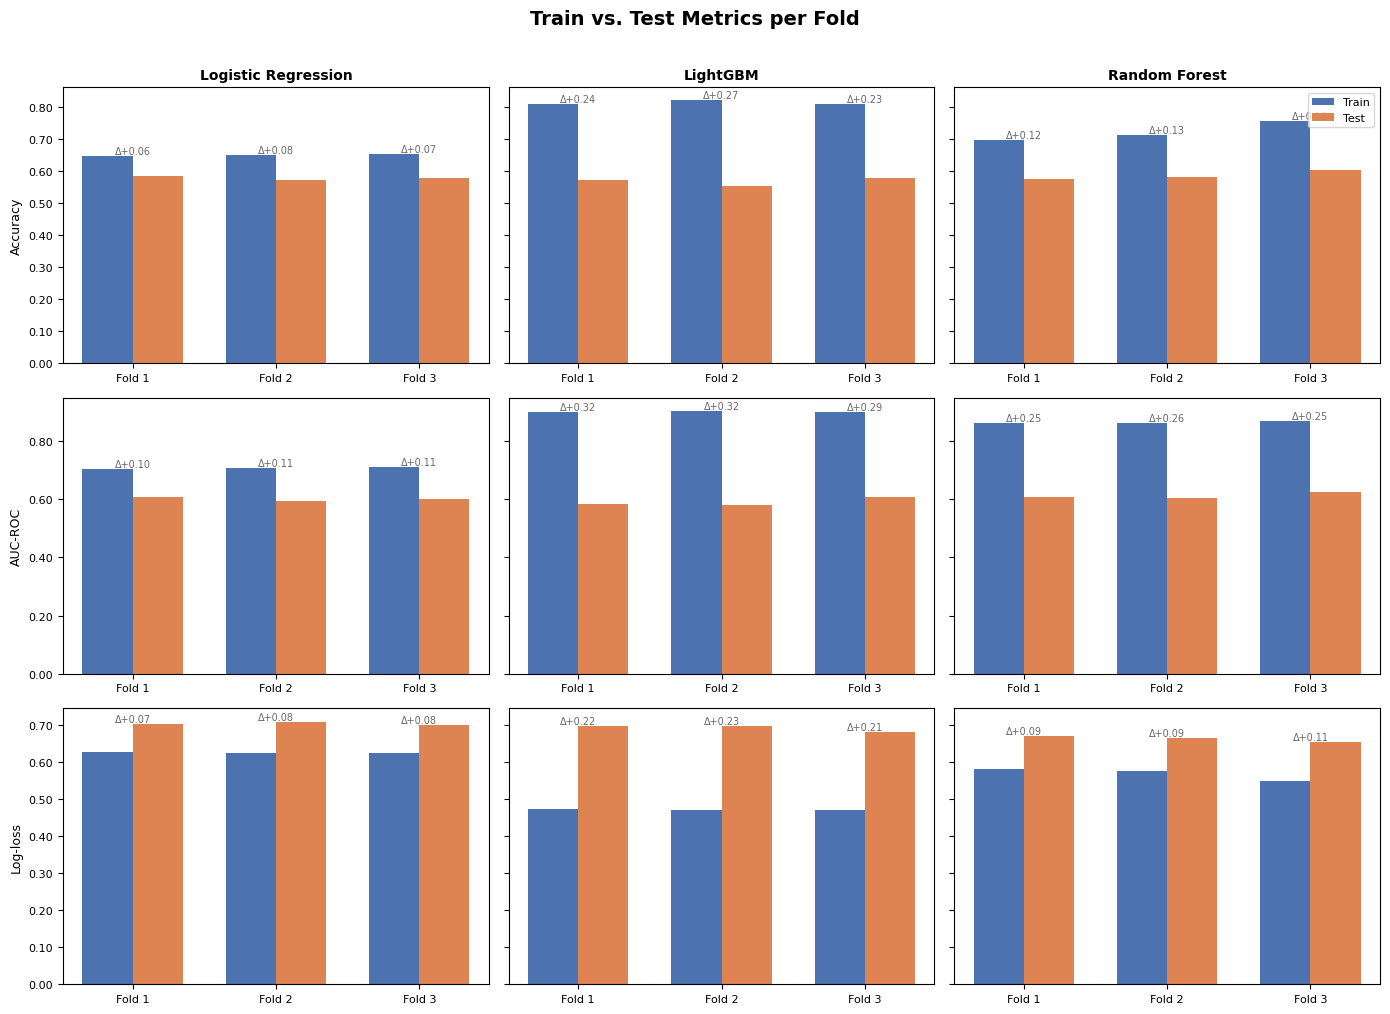

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

metrics_to_plot = ["accuracy", "auc", "logloss"]
metric_labels = {"accuracy": "Accuracy", "auc": "AUC-ROC", "logloss": "Log-loss"}
n_folds = len(FOLDS)
fold_labels = [f"Fold {i}" for i in range(1, n_folds + 1)]

x = np.arange(n_folds)
bar_width = 0.35

fig, axes = plt.subplots(
    nrows=len(metrics_to_plot),
    ncols=len(MODEL_NAMES),
    figsize=(14, 10),
    sharey="row",
)
fig.suptitle("Train vs. Test Metrics per Fold", fontsize=14, fontweight="bold", y=1.01)

for col, model_name in enumerate(MODEL_NAMES):
    train_res = intermediary_fold_results_train[model_name]
    test_res = intermediary_fold_results[model_name]

    for row, metric in enumerate(metrics_to_plot):
        ax = axes[row, col]
        train_vals = train_res[metric]
        test_vals = test_res[metric]

        bars_train = ax.bar(x - bar_width / 2, train_vals, bar_width, label="Train", color="#4C72B0")
        bars_test = ax.bar(x + bar_width / 2, test_vals, bar_width, label="Test", color="#DD8452")

        # Annotate gap direction
        for i, (tv, ev) in enumerate(zip(train_vals, test_vals)):
            gap = tv - ev
            # For log-loss, higher train is better (less overfit means lower loss)
            if metric == "logloss":
                gap = ev - tv  # positive gap = test worse = overfitting
            if abs(gap) > 0.05:
                ax.annotate(
                    f"Δ{gap:+.2f}",
                    xy=(x[i], max(tv, ev)),
                    ha="center", va="bottom", fontsize=7, color="dimgrey",
                )

        ax.set_xticks(x)
        ax.set_xticklabels(fold_labels, fontsize=8)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
        ax.tick_params(axis="y", labelsize=8)

        if row == 0:
            ax.set_title(model_name, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(metric_labels[metric], fontsize=9)
        if row == 0 and col == len(MODEL_NAMES) - 1:
            ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()